In [8]:
# coding: utf-8
import sys
sys.path.append('../..')
import numpy as np
from common import config
# GPU에서 실행하려면 아래 주석을 해제하세요(CuPy 필요).
# ===============================================
# config.GPU = True
# ===============================================
import pickle
from common.trainer import Trainer
from common.optimizer import Adam
from cbow import CBOW
from skip_gram import SkipGram
from common.util import create_contexts_target
from dataset import ptb

In [9]:
def to_cpu(x):
    import numpy
    if type(x) == numpy.ndarray:
        return x
    return np.asnumpy(x)

| 에폭 1 |  반복 1 / 9295 | 시간 0[s] | 손실 4.16
| 에폭 1 |  반복 21 / 9295 | 시간 0[s] | 손실 4.16
| 에폭 1 |  반복 41 / 9295 | 시간 0[s] | 손실 4.15
| 에폭 1 |  반복 61 / 9295 | 시간 1[s] | 손실 4.12
| 에폭 1 |  반복 81 / 9295 | 시간 1[s] | 손실 4.05
| 에폭 1 |  반복 101 / 9295 | 시간 2[s] | 손실 3.93
| 에폭 1 |  반복 121 / 9295 | 시간 2[s] | 손실 3.78
| 에폭 1 |  반복 141 / 9295 | 시간 2[s] | 손실 3.62
| 에폭 1 |  반복 161 / 9295 | 시간 3[s] | 손실 3.48
| 에폭 1 |  반복 181 / 9295 | 시간 3[s] | 손실 3.35
| 에폭 1 |  반복 201 / 9295 | 시간 4[s] | 손실 3.24
| 에폭 1 |  반복 221 / 9295 | 시간 4[s] | 손실 3.16
| 에폭 1 |  반복 241 / 9295 | 시간 5[s] | 손실 3.07
| 에폭 1 |  반복 261 / 9295 | 시간 5[s] | 손실 3.03
| 에폭 1 |  반복 281 / 9295 | 시간 5[s] | 손실 2.97
| 에폭 1 |  반복 301 / 9295 | 시간 6[s] | 손실 2.90
| 에폭 1 |  반복 321 / 9295 | 시간 6[s] | 손실 2.88
| 에폭 1 |  반복 341 / 9295 | 시간 7[s] | 손실 2.82
| 에폭 1 |  반복 361 / 9295 | 시간 7[s] | 손실 2.81
| 에폭 1 |  반복 381 / 9295 | 시간 7[s] | 손실 2.78
| 에폭 1 |  반복 401 / 9295 | 시간 8[s] | 손실 2.77
| 에폭 1 |  반복 421 / 9295 | 시간 8[s] | 손실 2.76
| 에폭 1 |  반복 441 / 9295 | 시간 9[s] | 손실

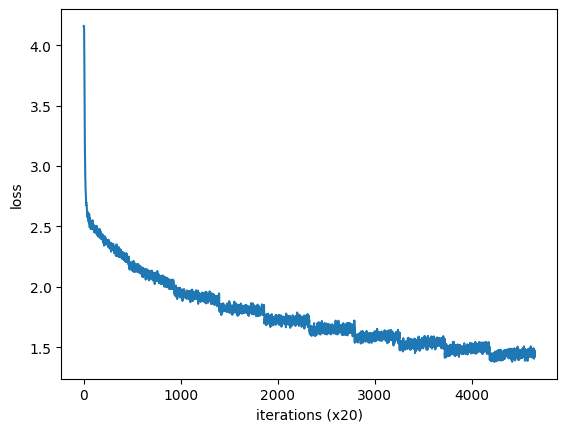

In [10]:
# 하이퍼파라미터 설정
window_size = 5
hidden_size = 100
batch_size = 100
max_epoch = 10

# 데이터 읽기
corpus, word_to_id, id_to_word = ptb.load_data('train')
vocab_size = len(word_to_id)

contexts, target = create_contexts_target(corpus, window_size)
if config.GPU:
    contexts, target = to_cpu(contexts), to_cpu(target)

# 모델 등 생성
model = CBOW(vocab_size, hidden_size, window_size, corpus)
# model = SkipGram(vocab_size, hidden_size, window_size, corpus)
optimizer = Adam()
trainer = Trainer(model, optimizer)

# 학습 시작
trainer.fit(contexts, target, max_epoch, batch_size)
trainer.plot()

# 나중에 사용할 수 있도록 필요한 데이터 저장
word_vecs = model.word_vecs
if config.GPU:
    word_vecs = to_cpu(word_vecs)
params = {}
params['word_vecs'] = word_vecs.astype(np.float16)
params['word_to_id'] = word_to_id
params['id_to_word'] = id_to_word
pkl_file = 'cbow_params.pkl'  # or 'skipgram_params.pkl'
with open(pkl_file, 'wb') as f:
    pickle.dump(params, f, -1)